# Lab 14 (Week 3 — Lab 4): Recurrent Neural Networks & Sequence Data

**Name:** Numair Fahad

**Role:** AI/ML Intern

**Company:** Zynvex Solutions

**GitHub:** https://github.com/numair-2003/AIML-Internship-NumairFahad


Welcome to Lab 14! In this lab you will build a Recurrent Neural Network (using LSTM) for text classification — predicting whether a movie review is positive or negative.

**For detailed theory on RNNs, LSTMs, and sequence preparation, see the Lab 14 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.
- Training on sequence data can take a few minutes per run — be patient.

## Getting the Dataset

This lab uses the IMDB Movie Reviews dataset, built directly into Keras — no download or upload needed. Reviews are already converted to sequences of word-index integers.

In [17]:
from tensorflow import keras
import numpy as np

vocab_size = 10000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

print("Training reviews:", len(X_train))
print("Test reviews:", len(X_test))
print("First review (word indices):", X_train[0][:20])
print("First review's label (0=negative, 1=positive):", y_train[0])

Training reviews: 25000
Test reviews: 25000
First review (word indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First review's label (0=negative, 1=positive): 1


## Decoding a Review Back to Words

Just to see what the data actually represents, here's how to turn word indices back into readable text.

In [18]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print(decode_review(X_train[0]))
print("\nLabel:", "Positive" if y_train[0] == 1 else "Negative")

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wha

## Preparing the Data: Padding Sequences

Reviews vary in length, but the network needs a fixed input size. We'll pad/truncate every review to 200 words.

In [19]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 200
X_train_padded = pad_sequences(X_train, maxlen=maxlen)
X_test_padded = pad_sequences(X_test, maxlen=maxlen)

print("Padded shape:", X_train_padded.shape)
print("Example padded review:", X_train_padded[0][:20], "...")

Padded shape: (25000, 200)
Example padded review: [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2] ...


## Example 1: Building an LSTM Model

In [20]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

## Example 2: Compiling & Training

To keep training time reasonable, we'll train on a subset first.

In [21]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_padded[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 94ms/step - accuracy: 0.6764 - loss: 0.5796 - val_accuracy: 0.8510 - val_loss: 0.3604
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.8840 - loss: 0.2962 - val_accuracy: 0.8690 - val_loss: 0.3171
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.9325 - loss: 0.1872 - val_accuracy: 0.8630 - val_loss: 0.3305
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.9615 - loss: 0.1227 - val_accuracy: 0.8585 - val_loss: 0.4227
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.9780 - loss: 0.0771 - val_accuracy: 0.8505 - val_loss: 0.4265


## Example 3: Visualizing Training Progress

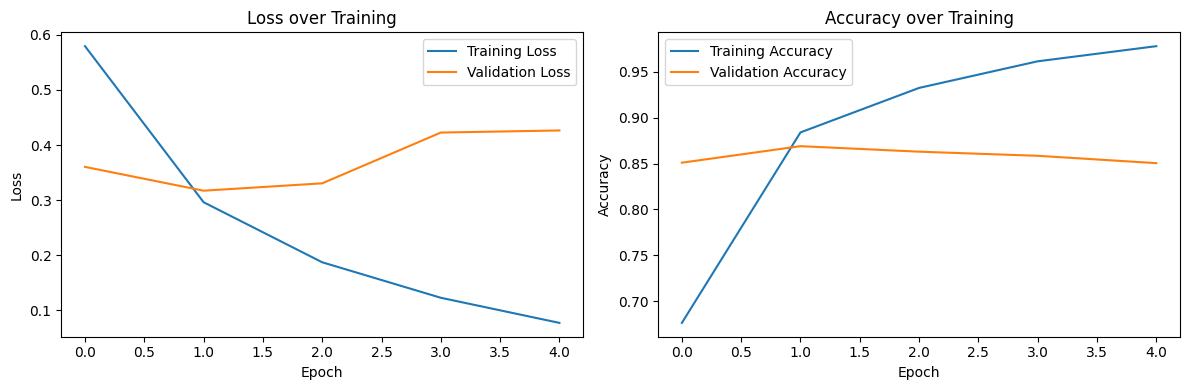

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training")

plt.tight_layout()
plt.show()

## Example 4: Evaluating and Predicting on New Reviews

In [23]:
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

sample_predictions = model.predict(X_test_padded[:5], verbose=0)
for i in range(5):
    sentiment = "Positive" if sample_predictions[i][0] > 0.5 else "Negative"
    actual = "Positive" if y_test[i] == 1 else "Negative"
    print(f"Predicted: {sentiment} ({sample_predictions[i][0]:.2f}) | Actual: {actual}")

Test Accuracy: 0.8418
Predicted: Negative (0.04) | Actual: Negative
Predicted: Positive (1.00) | Actual: Positive
Predicted: Positive (0.99) | Actual: Positive
Predicted: Negative (0.17) | Actual: Negative
Predicted: Positive (1.00) | Actual: Positive


## Practice Exercise 1: Try a GRU Instead of LSTM

**Exercise:** Rebuild the model from Example 1, but replace `layers.LSTM(32)` with `layers.GRU(32)`. Train on the same 10,000-review subset for 5 epochs and compare test accuracy and training time to the LSTM version.

In [24]:
### YOUR CODE HERE ###
import time

model_gru = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.GRU(32),
    layers.Dense(1, activation="sigmoid")
])

model_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start_train_time_gru = time.time()

history_model_gru = model_gru.fit(
    X_train_padded[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

final_train_time_gru = time.time() - start_train_time_gru

test_loss_gru, test_accuracy_gru = model.evaluate(X_test_padded, y_test, verbose=0)

print(f"Training time (GRU): {final_train_time_gru:.1f}s")
### END ###

print("Test accuracy (GRU):", test_accuracy_gru)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.6511 - loss: 0.6129 - val_accuracy: 0.7855 - val_loss: 0.4594
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.8629 - loss: 0.3279 - val_accuracy: 0.8470 - val_loss: 0.3621
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - accuracy: 0.9190 - loss: 0.2153 - val_accuracy: 0.8515 - val_loss: 0.3828
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.9536 - loss: 0.1332 - val_accuracy: 0.8450 - val_loss: 0.4345
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.9696 - loss: 0.0969 - val_accuracy: 0.8400 - val_loss: 0.4851
Training time (GRU): 83.0s
Test accuracy (GRU): 0.841759979724884


### **GRU vs LSTM test accuracies and training time**

- **Test accuracy** was **almost identical between the GRU and LSTM**, i.e. **0.8430 (LSTM)** against **0.8418 (GRU)**. This shows there is **almost no difference between them** in **this run**, which confirms that **GRU can match LSTM's performance** despite its **simpler gating mechanism**.

- **Training time** was **higher for GRU** (**83.0s**) than **LSTM's approximate total training time** (**~55s**, summing the per-epoch times: **13 + 11 + 10 + 11 + 10s**). This is **a bit opposite to the usual expectation** that **GRU trains faster than LSTM** due to **fewer parameters**, because in **this run**, **GRU took noticeably longer than LSTM**, which is likely due to **per-epoch runtime variance** (e.g., **epoch 4 of GRU alone took 20s**) rather than any **fundamental inefficiency in GRU itself**.

As a whole, **GRU achieved essentially the same test accuracy as LSTM**, **without a training-time advantage** in **this specific run**.

## Practice Exercise 2: Changing Sequence Length

**Exercise:** Re-pad the reviews using `maxlen=100` instead of 200. Rebuild and retrain the LSTM model from Example 1 with this shorter sequence length. Compare test accuracy and training time to the original.

In [25]:
### YOUR CODE HERE ###
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen_shortened = 100
X_train_padded_100 = pad_sequences(X_train, maxlen=maxlen_shortened)
X_test_padded_100 = pad_sequences(X_test, maxlen=maxlen_shortened)

model_100 = keras.Sequential([
    layers.Input(shape=(maxlen_shortened,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

model_100.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start_train_time_100 = time.time()

history_model_100 = model_100.fit(
    X_train_padded_100[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

final_train_time_100 = time.time() - start_train_time_100

test_loss_100, test_accuracy_100 = model_100.evaluate(X_test_padded_100, y_test, verbose=0)

print(f"Test accuracy (maxlen=100): {test_accuracy_100:.4f}")
print(f"Training time (maxlen=100): {final_train_time_100:.1f}s")
print(f"Test accuracy - Original LSTM (maxlen=200): {test_accuracy:.4f}")
### END ###

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.6977 - loss: 0.5643 - val_accuracy: 0.8380 - val_loss: 0.3920
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.8749 - loss: 0.3117 - val_accuracy: 0.8330 - val_loss: 0.3915
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.9315 - loss: 0.1913 - val_accuracy: 0.8340 - val_loss: 0.4027
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9589 - loss: 0.1255 - val_accuracy: 0.8200 - val_loss: 0.5000
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9715 - loss: 0.0900 - val_accuracy: 0.8280 - val_loss: 0.4976
Test accuracy (maxlen=100): 0.8170
Training time (maxlen=100): 46.0s
Test accuracy - Original LSTM (maxlen=200): 0.8418


### **Original (maxlen=200) vs Shortened version (maxlen=100) of LSTM (test accuracies and training time)**

- **Test accuracy dropped with the shortened sequence length** from **0.8418** (maxlen=200) to **0.8170** (maxlen=100), which shows a **decrease of about 2.5 percentage points**. This is because **truncating reviews to 100 words cuts off roughly half of each review's content**, and so, the **important sentiment-bearing context**, especially **in longer reviews**, is **lost**.

- **Training time** was **faster with the maxlen=100 run** (i.e. **total 46.0s across 5 epochs**, e.g., **9 + 6 + 11 + 10 + 5s**) compared to the **original maxlen=200 run** (**total ~66s**, e.g., **14 + 12 + 18 + 11 + 11s**), since the **LSTM processes half as many timesteps per sequence** with the **shortened maxlen**.

Overall, the **maxlen=100 run trains noticeably faster than the maxlen=200 run**, yet **drops meaningful test accuracy**, whereas **maxlen=200 run takes longer to train**, but **preserves more of the review's content** and **achieves better sentiment classification performance**.

## Practice Exercise 3: Predicting Your Own Review

**Exercise:** Write your own short movie review as a Python string (2-3 sentences). Convert it to word indices using the `word_index` dictionary from earlier (map each word to its index, using 2 for unknown words, then add 3 to match the dataset's offset), pad it to `maxlen=200`, and predict its sentiment using your trained model.

In [26]:
my_review = "This movie was absolutely wonderful and I loved every minute of it"

### YOUR CODE HERE ###
words = my_review.lower().split()

encoded_review = [1]
for word in words:
  index = word_index.get(word, 2 - 3)
  encoded_review.append(index + 3)

my_review_padded = pad_sequences([encoded_review], maxlen=maxlen)

model_prediction = model.predict(my_review_padded, verbose=0)
sentiment = "Positive" if model_prediction[0][0] > 0.5 else "Negative"

print(f"Review: {my_review}")
print(f"Predicted sentiment: {sentiment} (Prediction score: {model_prediction[0][0]:.4f})")
### END ###

Review: This movie was absolutely wonderful and I loved every minute of it
Predicted sentiment: Positive (Prediction score: 0.7801)


## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Build & Train Your Own Model**: Design your own architecture (try stacking 2 LSTM layers, or changing the embedding/LSTM unit sizes). Train on at least 10,000 reviews and report test accuracy.
2. **RNN Type Comparison**: Train the same architecture using SimpleRNN, GRU, and LSTM (keeping other settings constant). Create a comparison table of test accuracy and approximate training time for each.
3. **Sequence Length Experiment**: Try 3 different `maxlen` values (e.g., 50, 100, 200) with your best architecture. Report test accuracy for each and discuss the trade-off between sequence length and training time.
4. **Error Analysis**: Find 3 reviews in the test set that your best model misclassified. Print the decoded text (using `decode_review`) and the predicted vs. actual sentiment for each. In a markdown cell, speculate on why the model might have gotten these wrong.
5. **Reflection**: In a markdown cell, write 3-4 sentences on how processing sequence data (text) with an RNN differs from processing image data with a CNN (Lab 13), and why each architecture fits its respective data type.

In [27]:
# Task 1
from tensorflow import keras
from tensorflow.keras import layers

my_model = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

my_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

my_model.summary()

history_my_model = my_model.fit(
    X_train_padded[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

test_loss_my_model, test_accuracy_my_model = my_model.evaluate(X_test_padded, y_test, verbose=0)

print(f"Test Accuracy - My Model: {test_accuracy_my_model:.4f}")

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 200, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,985 (2.62 MB)

 Trainable params: 685,985 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - accuracy: 0.6616 - loss: 0.5986 - val_accuracy: 0.8000 - val_loss: 0.4446
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 222ms/step - accuracy: 0.8449 - loss: 0.3873 - val_accuracy: 0.8270 - val_loss: 0.3937
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 225ms/step - accuracy: 0.9199 - loss: 0.2320 - val_accuracy: 0.8585 - val_loss: 0.3808
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 228ms/step - accuracy: 0.9563 - loss: 0.1375 - val_accuracy: 0.8510 - val_loss: 0.4342
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 235ms/step - accuracy: 0.9551 - loss: 0.1363 - val_accuracy: 0.8155 - val_loss: 0.4536
Test Accuracy - My Model: 0.8099


In [28]:
# Task 2
import pandas as pd
import time

def build_rnn_model(layer_type):
  if layer_type == "SimpleRNN":
    recurrent_layer = layers.SimpleRNN(32)
  elif layer_type == "GRU":
    recurrent_layer = layers.GRU(32)
  elif layer_type == "LSTM":
    recurrent_layer = layers.LSTM(32)

  rnn_model = keras.Sequential([
      layers.Input(shape=(maxlen,)),
      layers.Embedding(input_dim=vocab_size, output_dim=32),
      recurrent_layer,
      layers.Dense(1, activation="sigmoid")
  ])

  rnn_model.compile(
      optimizer="adam",
      loss="binary_crossentropy",
      metrics=["accuracy"]
  )

  return rnn_model

results = []
for layer_type in ["SimpleRNN", "GRU", "LSTM"]:
  rnn_model = build_rnn_model(layer_type)
  start_train_time_rnn = time.time()

  rnn_model.fit(
      X_train_padded[:10000], y_train[:10000],
      epochs=5,
      batch_size=64,
      validation_split=0.2,
      verbose=1
  )

  final_train_time_rnn = time.time() - start_train_time_rnn

  test_loss_rnn, test_accuracy_rnn = rnn_model.evaluate(X_test_padded, y_test, verbose=0)
  results.append({"Model": layer_type, "Test Accuracy": round(test_accuracy_rnn, 4), "Training Time (in s)": round(final_train_time_rnn, 1)})

comparison_table_df = pd.DataFrame(results)
print(comparison_table_df)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.5986 - loss: 0.6557 - val_accuracy: 0.7630 - val_loss: 0.5273
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.7554 - loss: 0.5330 - val_accuracy: 0.7670 - val_loss: 0.5129
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.8920 - loss: 0.2954 - val_accuracy: 0.7835 - val_loss: 0.4724
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9586 - loss: 0.1351 - val_accuracy: 0.8050 - val_loss: 0.4602
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9912 - loss: 0.0510 - val_accuracy: 0.8085 - val_loss: 0.5034
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.6534 - loss: 0.6092 - val_accuracy: 0.8035 - val_loss: 0.4395
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.8648 - loss: 0.3230 - val_accuracy: 0.8370 - val_loss: 0.3942
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - accuracy: 0.9281 - loss: 0.1963 - val_accurac

In [29]:
# Task 3
maxlen_values = [50, 100, 200]
maxlen_results = []

for maximum_length in maxlen_values:
  X_train_maxlen = pad_sequences(X_train, maxlen=maximum_length)
  X_test_maxlen = pad_sequences(X_test, maxlen=maximum_length)

  model_maxlen = keras.Sequential([
      layers.Input(shape=(maximum_length,)),
      layers.Embedding(input_dim=vocab_size, output_dim=32),
      layers.LSTM(32),
      layers.Dense(1, activation="sigmoid")
  ])

  model_maxlen.compile(
      optimizer="adam",
      loss="binary_crossentropy",
      metrics=["accuracy"]
  )

  start_train_time_maxlen = time.time()

  model_maxlen.fit(
      X_train_maxlen[:10000], y_train[:10000],
      epochs=5,
      batch_size=64,
      validation_split=0.2,
      verbose=1
    )

  final_train_time_maxlen = time.time() - start_train_time_maxlen

  test_loss_maxlen, test_accuracy_maxlen = model_maxlen.evaluate(X_test_maxlen, y_test, verbose=0)
  maxlen_results.append({"Max Length": maximum_length, "Test Accuracy": round(test_accuracy_maxlen, 4), "Training Time (in s)": round(final_train_time_maxlen, 1)})

length_df = pd.DataFrame(maxlen_results)
print(length_df)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6784 - loss: 0.5962 - val_accuracy: 0.7745 - val_loss: 0.4638
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8414 - loss: 0.3608 - val_accuracy: 0.7810 - val_loss: 0.4569
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9078 - loss: 0.2358 - val_accuracy: 0.7865 - val_loss: 0.4857
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9454 - loss: 0.1575 - val_accuracy: 0.7780 - val_loss: 0.5724
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9674 - loss: 0.0994 - val_accuracy: 0.7745 - val_loss: 0.6948
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.6385 - loss: 0.6250 - val_accuracy: 0.8045 - val_loss: 0.4468
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8521 - loss: 0.3535 - val_accuracy: 0.8460 - val_loss: 0.3696
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9215 - loss: 0.2112 - val_accuracy: 0.

### **Trade-off between sequence length and training time**

- As **maxlen increases**, both **test accuracy and training time increase**. Shifting from **50 to 200 words**, **test accuracy improved** from **0.7696 to 0.8315**, showing a **gain of ~6.2 percentage points**, but **training time increased roughly 2.5 times** from **24.0s to 59.5s**, which represents a **much steeper increase** compared to the **test accuracy gain**.

- This is because the **LSTM model processes one timestep per word**, due to which **doubling the sequence length roughly doubles the computation per epoch**, and so, the **relationship is closer to linear-to-superlinear in training time**.

- On the other hand, **test accuracy gains show diminishing returns** such that the **increase in maxlen from 50 to 100 words** gained **~4.3 percentage points**, whereas **100 to 200 words** only gained **~1.9 percentage points**, which means that **each additional block of sequence length** contributes **less new sentiment information than the last**, which is likely because the **most decisive sentiment cues** in **a review** are **often concentrated rather than spread evenly throughout**.

In [30]:
# Task 4
predictions_all = model_maxlen.predict(X_test_maxlen, verbose=0)
predicted_labels_all = (predictions_all > 0.5).astype(int).flatten()

misclassified_reviews = []
for i in range(len(y_test)):
  if predicted_labels_all[i] != y_test[i]:
    misclassified_reviews.append(i)

  if len(misclassified_reviews) == 3:
    break

for idx in misclassified_reviews:
  predicted_sentiment = "Positive" if predicted_labels_all[idx] == 1 else "Negative"
  actual_sentiment = "Positive" if y_test[idx] == 1 else "Negative"

  print(f"Review {idx}:")
  print(f"Decoded Text: {decode_review(X_test[idx])}")
  print(f"Predicted Sentiment: {predicted_sentiment}  |  Actual Sentiment: {actual_sentiment}\n")

Review 8:
Decoded Text: <START> hollywood had a long love affair with bogus <UNK> nights tales but few of these products have stood the test of time the most memorable were the jon hall maria <UNK> films which have long since become camp this one is filled with dubbed songs <UNK> <UNK> and slapstick it's a truly crop of corn and pretty near <UNK> today it was nominated for its imaginative special effects which are almost <UNK> in this day and age <UNK> mainly of trick photography the only outstanding positive feature which survives is its beautiful color and clarity sad to say of the many films made in this genre few of them come up to alexander <UNK> original thief of <UNK> almost any other <UNK> nights film is superior to this one though it's a loser
Predicted Sentiment: Positive  |  Actual Sentiment: Negative

Review 49:
Decoded Text: <START> i can't understand why imdb users would rate this movie 5 2 10 it really is great very funny i would strongly recommend this movie for all of 

### **Why the model might have gotten these wrong?**

The model might have gotten them wrong because **all three misclassified reviews mix positive and negative signals**, and **each shares a pattern**: they contain **content that would mislead a model relying on surface-level word cues** rather than **weighing the full context or unconventional structure**. This infers that the **model is only picking up on the presence of individual sentiment words without correctly weighing nearby qualifying, negating, or contrasting language**.

- **Review 8 praises specific old films** as "**memorable**" **before criticizing the broader genre**, such that the **scattered positive words about a few exceptions** likely **outweighed the negative framing of the whole**.

- **Review 49 is written in informal, unconventional language** (i.e. "**5 2 10**" **instead of** "**5.2/10**," **casual grammar**, **self-admitted** "my **english isn't good enough**") despite being **clearly and strongly positive**, which likely **confused the model's ability to pick up the sentiment**.

- **Review 55 uses long, literary, abstract language** (i.e. "**pure movie world**," "**visual yearning**") rather than **direct sentiment words**, such that the **model likely failed to extract a clear positive signal**, focusing on the **absence of obvious positive words instead**.


## **Task 5**

A **CNN exploits spatial locality/structure** of the **provided data** (**images**) by **filtering scan fixed 2D positions**, **assuming neighbouring pixels are related regardless of direction**. On the contrary, an **RNN processes sequence data** (**text**) **one element at a time** in an **orderly manner**; therefore, **maintaining a hidden state** that **carries information forward**. This is because **what comes before affects the meaning of what comes after**, and so, **dependencies can span far apart**.

This matters because **shuffling pixels** in a **small neighborhood** **barely changes an image**, yet **shuffling words** in a **sentence** can **ruin its meaning**.

**CNNs fit spatial**, **position-invariant data**, whereas **RNNs/LSTMs fit variable-length**, **order-dependent data sequences**, where **each architecture matches** the **structural assumption its data type requires**.

In [31]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 148 (delta 67), reused 78 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 31.63 MiB | 22.31 MiB/s, done.
Resolving deltas: 100% (67/67), done.


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Lab 14_NumairFahad.ipynb" "/content/your-repo/"